In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits

In [4]:
import os
from pathlib import Path
import sys

In [5]:
from astropy.coordinates import SkyCoord

In [6]:
import pandas as pd

In [7]:
ibisdir = Path("/global/cfs/cdirs/cosmo/work/legacysurvey/ibis/reductions")
# fpath = "/global/cfs/cdirs/cosmo/work/legacysurvey/ibis/reductions/ibis3/coadd/032/0329m042/legacysurvey-0329m042-maskbits.fits.fz"
# with fits.open(fpath) as hdul:
#     maskbits = hdul[1].data

In [30]:
randtab_path = Path("/Users/yufengluo/Research/desi/random-catalog")
dirname = 'ibis3'
# "randoms-reductions-ibis3-bail-1.fits", "randoms-reductions-ibis3-1.fits"
fname = "randoms-reductions-ibis3-1.fits"
randtab = Table.read(randtab_path / fname)

In [9]:
# import seaborn as sns
# sfig = sns.jointplot(data=df, x='RA', y='DEC', kind='scatter',
#                      s=0.1, marginal_ticks=True)
# sfig.set_axis_labels('RA (deg)', 'DEC (deg)')
# sfig.figure.savefig('rand-ra-dec.png')

## find all ra and dec for observed targets

In [8]:
rootdir = ibisdir / dirname

In [9]:
coadddir = rootdir / 'coadd'
tracdir = rootdir / 'tractor'

In [10]:
tracdir

PosixPath('/global/cfs/cdirs/cosmo/work/legacysurvey/ibis/reductions/ibis3/tractor')

In [11]:
# filters = ['M411', 'M438', 'M464', 'M490', 'M517']
# filt_obs = {filt: [] for filt in filters}
# from desiutil.log import get_logger
# from astropy.wcs import WCS


# log = get_logger()
# for path in rootdir.glob("*"):
#     for brpath in path.glob("*"):
#         # legacysurvey-0380m055-nexp-M411.fits.fz
#         for filt in filters:
#             fname = brpath / f"legacysurvey-{brpath.name}-nexp-{filt}.fits.fz"
#             if fname.exists():
#                 log.info(f"Reading {fname}")
#                 with fits.open(fname) as hdul:
#                     wcs = WCS(hdul[1].header)
#                     # pick which pixel has non-zero value for observations
#                     pixii = np.vstack(np.where(hdul[1].data > 0)).T
#                     coords = wcs.pixel_to_world(pixii[:, 1], pixii[:, 0])
#                     nobs = hdul[1].data[pixii[:, 0], pixii[:, 1]]
#                     filt_obs[filt].append((coords, nobs))

coords  = []
brname = []
for path in tracdir.glob("*"):
    for brpath in path.glob("tractor-*"):
        brname.append(brpath.name)
        dtab = Table.read(brpath)
        coords.append((dtab['ra'].data, dtab['dec'].data))
datcoords = np.hstack(coords).T
bricks = [br.split('-')[1].split('.')[0] for br in brname]
# np.save('bricks.npy', bricks)
# np.save('coords.npy', datcoords)

ValueError: need at least one array to concatenate

In [23]:
import pickle


rootdir = randtab_path
bricks = np.load(rootdir / 'bricks.npy').tolist()
datcoords = np.load(rootdir / 'allcoords.npy')
with open(rootdir / 'coords.pkl', 'rb') as f:
    coords = pickle.load(f)

In [24]:
# import pandas as pd
# dfrand = pd.DataFrame({'ra': randtab['RA'], 'dec': randtab['DEC']})
# dfrand['type'] = 'random'
# dfdata = pd.DataFrame({'ra': datcoords[:, 0], 'dec': datcoords[:, 1]})
# dfdata['type'] = 'tractor'
# sfig = sns.jointplot(data=df, x='ra', y='dec', kind='kde',
#                      marginal_ticks=True, hue='type')

In [11]:
# outdir = Path("/global/u1/b/brookluo/desi-ops/random-catalog") / dirname
outdir = Path('/Users/yufengluo/Research/desi/random-catalog')
outdir.mkdir(exist_ok=True)

## Making general plots for randoms

In [31]:
# remove rows where nobs == 0 for all filters
picknobs = np.zeros(len(randtab), dtype=bool)
filt_obs = ['M411', 'M438', 'M464', 'M490', 'M517']
for filt in filt_obs:
    nobs = randtab[f'NOBS_{filt}'] > 0
    picknobs |= nobs

In [33]:
len(randtab), np.sum(picknobs)

(19425629, 17038949)

In [34]:
np.sum(~picknobs) / np.sum(picknobs)

0.1400720197002761

In [35]:
oldtab = randtab
randtab = randtab[picknobs]

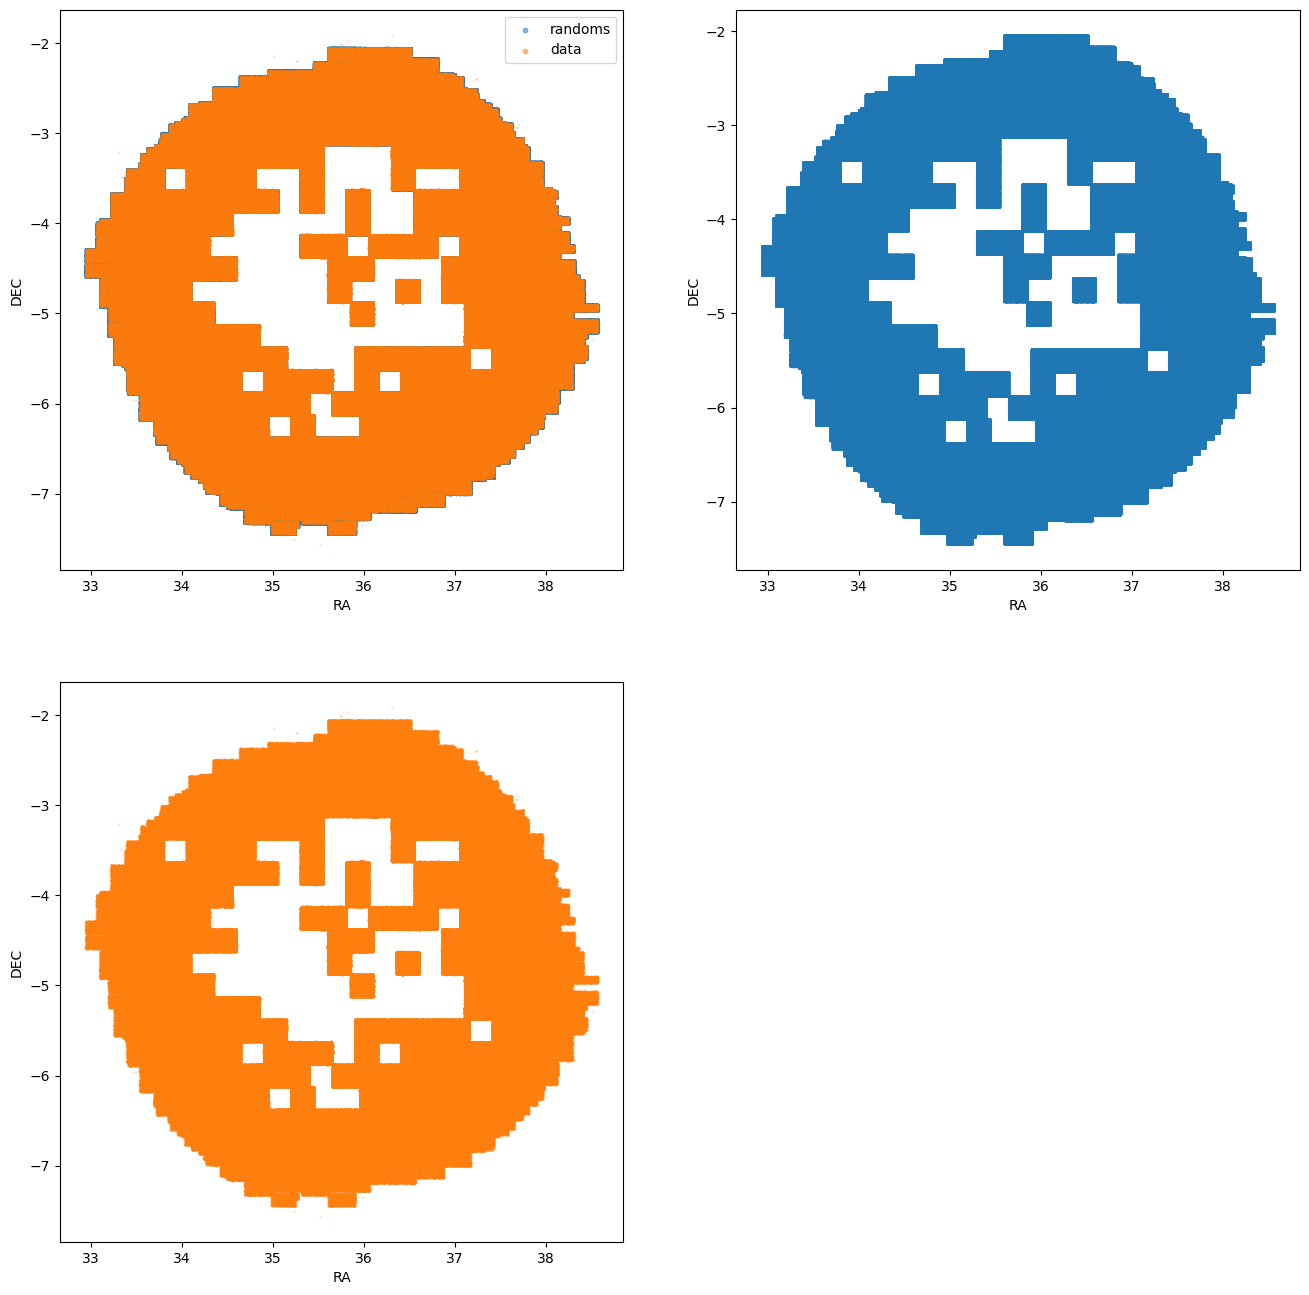

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(16, 16))
ax = ax.ravel()
ax[0].scatter(randtab['RA'], randtab['DEC'], s=0.1, label='randoms', alpha=0.5)
ax[0].scatter(datcoords[:, 0], datcoords[:, 1], s=0.1, label='data', alpha=0.5)
ax[1].scatter(randtab['RA'], randtab['DEC'], s=0.1, label='randoms', alpha=0.5)
ax[2].scatter(datcoords[:, 0], datcoords[:, 1], s=0.1, label='data', alpha=0.5,
              c='tab:orange')
ax[3].axis('off')
ax[0].legend(markerscale=10)
ax[0].set_xlabel('RA')
ax[0].set_ylabel('DEC')
ax[1].set_xlabel('RA')
ax[1].set_ylabel('DEC')
ax[2].set_xlabel('RA')
ax[2].set_ylabel('DEC')

fig.savefig(outdir / f"{dirname}-radec-2d-comparison.png")

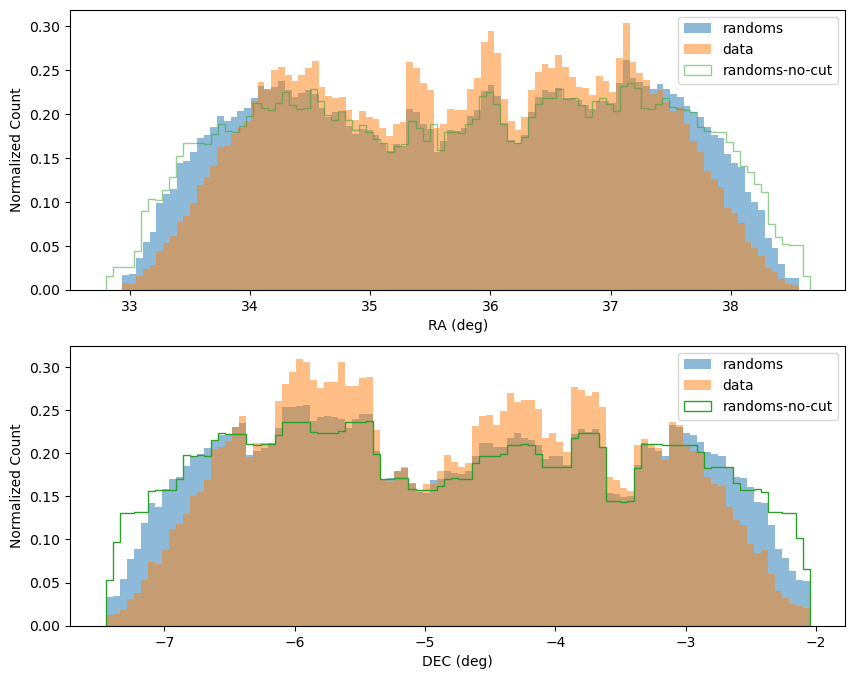

In [37]:
# RA, Dec distribution
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
# count, bins, patches = ax[0].hist(randtab['RA'], density=True, alpha=0.5, bins=100, label='randoms')
# ax[0].hist(datcoords[:, 0], bins=bins, density=True, alpha=0.5)
# count, bins, patches = ax[1].hist(randtab['DEC'], bins=100)
# ax[1].hist(datcoords[:, 1], bins=bins)


# Normalize the histograms
count, bins, patches = ax[0].hist(randtab['RA'], bins=100, density=True, alpha=0.5, label='randoms')
ax[0].hist(datcoords[:, 0], bins=bins, density=True, alpha=0.5, label='data')
ax[0].hist(oldtab['RA'], bins=100, density=True, alpha=0.5, label='randoms-no-cut', histtype='step')
ax[0].legend()
ax[0].set_xlabel('RA (deg)')

count, bins, patches = ax[1].hist(randtab['DEC'], bins=100, density=True, alpha=0.5, label='randoms')
ax[1].hist(datcoords[:, 1], bins=bins, density=True, alpha=0.5, label='data')
ax[1].hist(oldtab['DEC'], bins=bins, density=True, label='randoms-no-cut', histtype='step')
ax[1].legend()
ax[1].set_xlabel('DEC (deg)')
ax[0].set_ylabel('Normalized Count')
ax[1].set_ylabel('Normalized Count')

fig.savefig(outdir / f"{dirname}-radec-1d-dist.png")

## Check brick uniformity

In [38]:
ratio = len(datcoords) / len(randtab)

In [39]:
randbrnames, randcounts = np.unique(randtab['BRICKNAME'], return_counts=True)

In [40]:
brratios = []
for i, b in enumerate(bricks):
    # check the number of objects in each bricks
    # this should be close to 1
    np.where(randbrnames == b)[0]
    randnum = randcounts[np.where(randbrnames == bricks[4])[0]]
    brratio = randnum / len(coords[i][0]) * ratio
    brratios.append(brratio[0])

In [41]:
df = pd.DataFrame({'brick': bricks, 'ratio': brratios})

In [42]:
df.sort_values('ratio', ascending=False, inplace=True)

In [43]:
def parse_brickname(brick):
    if 'm' in brick:
        ra, dec = brick.split('m')
        dec = '-' + dec
    else:
        ra, dec = brick.split('p')
        dec = '+' + dec
    ra = int(ra) / 10
    dec = int(dec) / 10
    return ra, dec

In [44]:
df['ra'] = df['brick'].apply(lambda x: parse_brickname(x)[0])
df['dec'] = df['brick'].apply(lambda x: parse_brickname(x)[1])

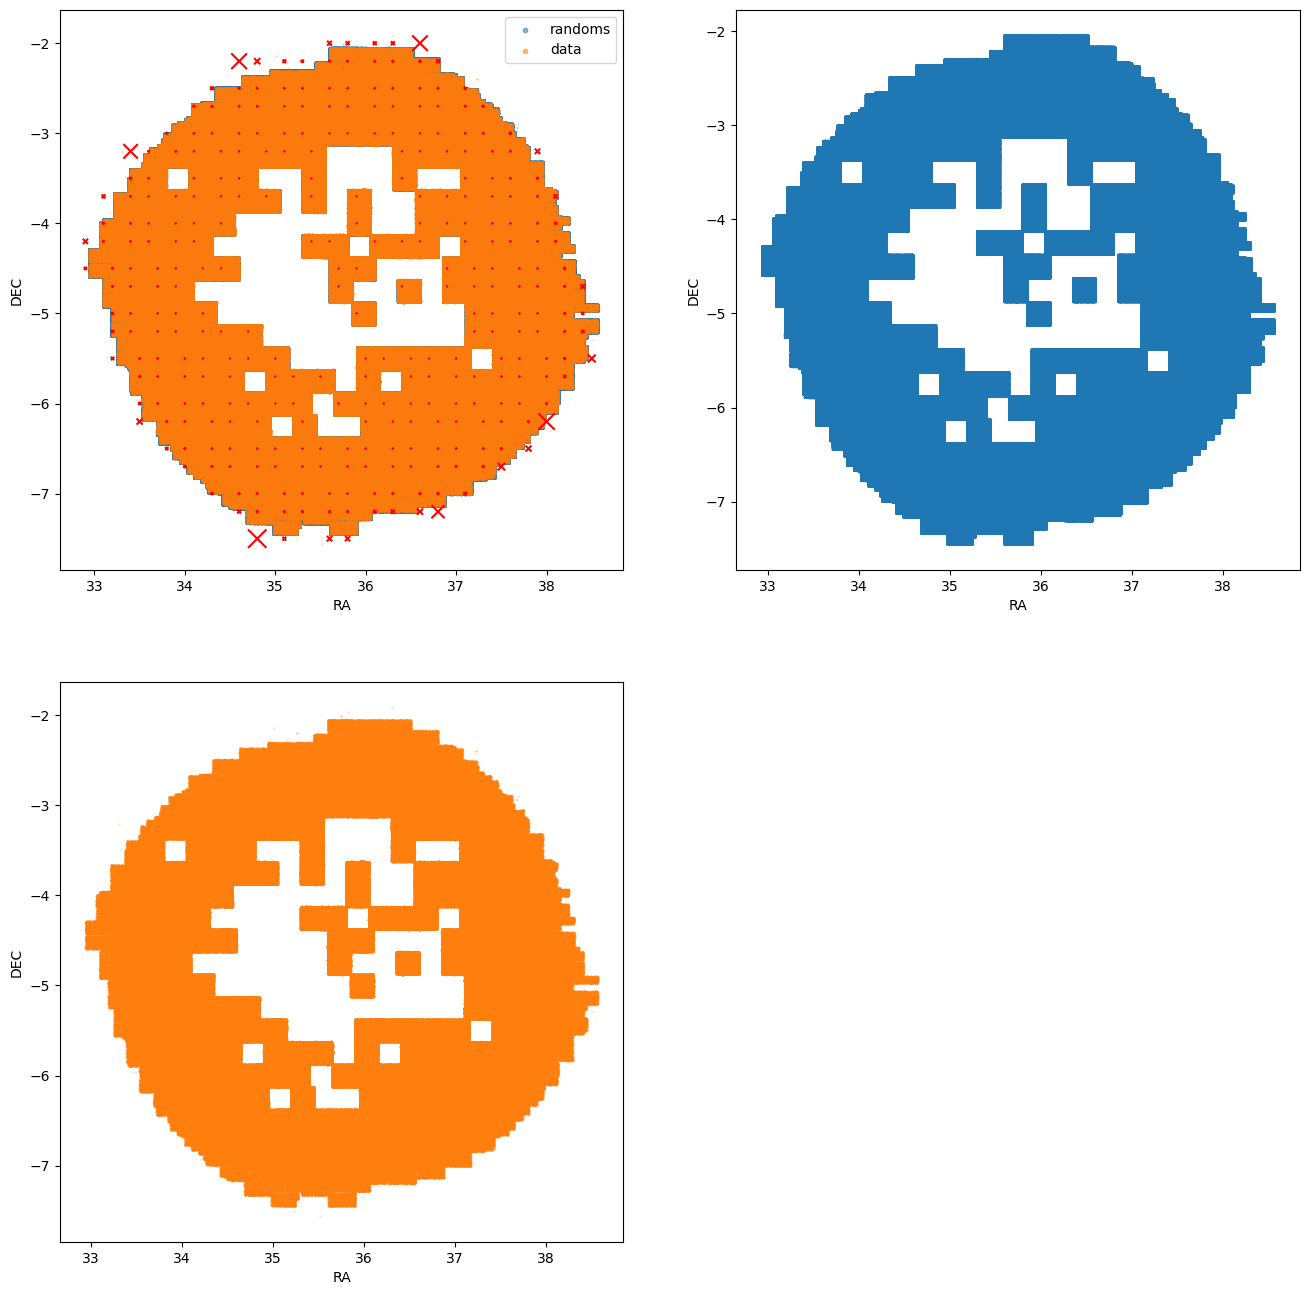

In [45]:
fig, ax = plt.subplots(2, 2, figsize=(16, 16))
ax = ax.ravel()
ax[0].scatter(randtab['RA'], randtab['DEC'], s=0.1, label='randoms', alpha=0.5)
ax[0].scatter(datcoords[:, 0], datcoords[:, 1], s=0.1, label='data', alpha=0.5)
ax[0].scatter(df['ra'], df['dec'], zorder=1000, s=df['ratio'], marker='x', color='r')# label='random to data Ratio')
ax[1].scatter(randtab['RA'], randtab['DEC'], s=0.1, label='randoms', alpha=0.5)
ax[2].scatter(datcoords[:, 0], datcoords[:, 1], s=0.1, label='data', alpha=0.5,
              c='tab:orange')
ax[3].axis('off')
ax[0].legend(markerscale=10)
ax[0].set_xlabel('RA')
ax[0].set_ylabel('DEC')
ax[1].set_xlabel('RA')
ax[1].set_ylabel('DEC')
ax[2].set_xlabel('RA')
ax[2].set_ylabel('DEC')

# ax[0].set_xlabel('RA')
# ax.set_ylabel('DEC')
# ax.set_title('Brick Ratio')
fig.savefig(outdir / f"{dirname}-radec-2d-comparison-coverage.png")

In [46]:
df.to_csv(outdir / "bricks-source-comparison.csv", index_label=False)

## Find bricks with largest difference

In [47]:
def plot_compare_randoms_data(randRA, randDEC, dataRA, dataDEC, outfile=None):
    fig, ax = plt.subplots(2, 2, figsize=(16, 16))
    ax = ax.ravel()
    ax[0].scatter(randRA, randDEC, s=1, label='randoms', alpha=0.5)
    ax[0].scatter(dataRA, dataDEC, s=1, label='data', alpha=0.5)
    ax[1].scatter(randRA, randDEC, s=1, label='randoms', alpha=0.5)
    ax[2].scatter(dataRA, dataDEC, s=1, label='data', alpha=0.5,
                c='tab:orange')
    # use the same axis range and aspect ratio
    xlim = ax[0].get_xlim()
    ylim = ax[0].get_ylim()
    ax[1].set_xlim(xlim)
    ax[2].set_xlim(xlim)
    ax[1].set_ylim(ylim)
    ax[2].set_ylim(ylim)
    ax[3].axis('off')
    ax[0].legend(markerscale=10)
    ax[0].set_xlabel('RA')
    ax[0].set_ylabel('DEC')
    ax[1].set_xlabel('RA')
    ax[1].set_ylabel('DEC')
    ax[2].set_xlabel('RA')
    ax[2].set_ylabel('DEC')
    if outfile:
        fig.savefig(outfile)
    return fig

The block with extreme ratio is: 0348m075 with ratio: 175.939241029479
The block with extreme ratio is: 0380m062 with ratio: 137.55249753213812
The block with extreme ratio is: 0346m022 with ratio: 128.22690447911182
The block with extreme ratio is: 0366m020 with ratio: 126.08978940445996
The block with extreme ratio is: 0334m032 with ratio: 108.07696234667996
The block with extreme ratio is: 0368m072 with ratio: 90.06413528889996
The block with extreme ratio is: 0385m055 with ratio: 31.39164881438837
The block with extreme ratio is: 0375m067 with ratio: 29.209989823427016
The block with extreme ratio is: 0348m022 with ratio: 20.014252286422217
The block with extreme ratio is: 0366m072 with ratio: 19.961444232896035


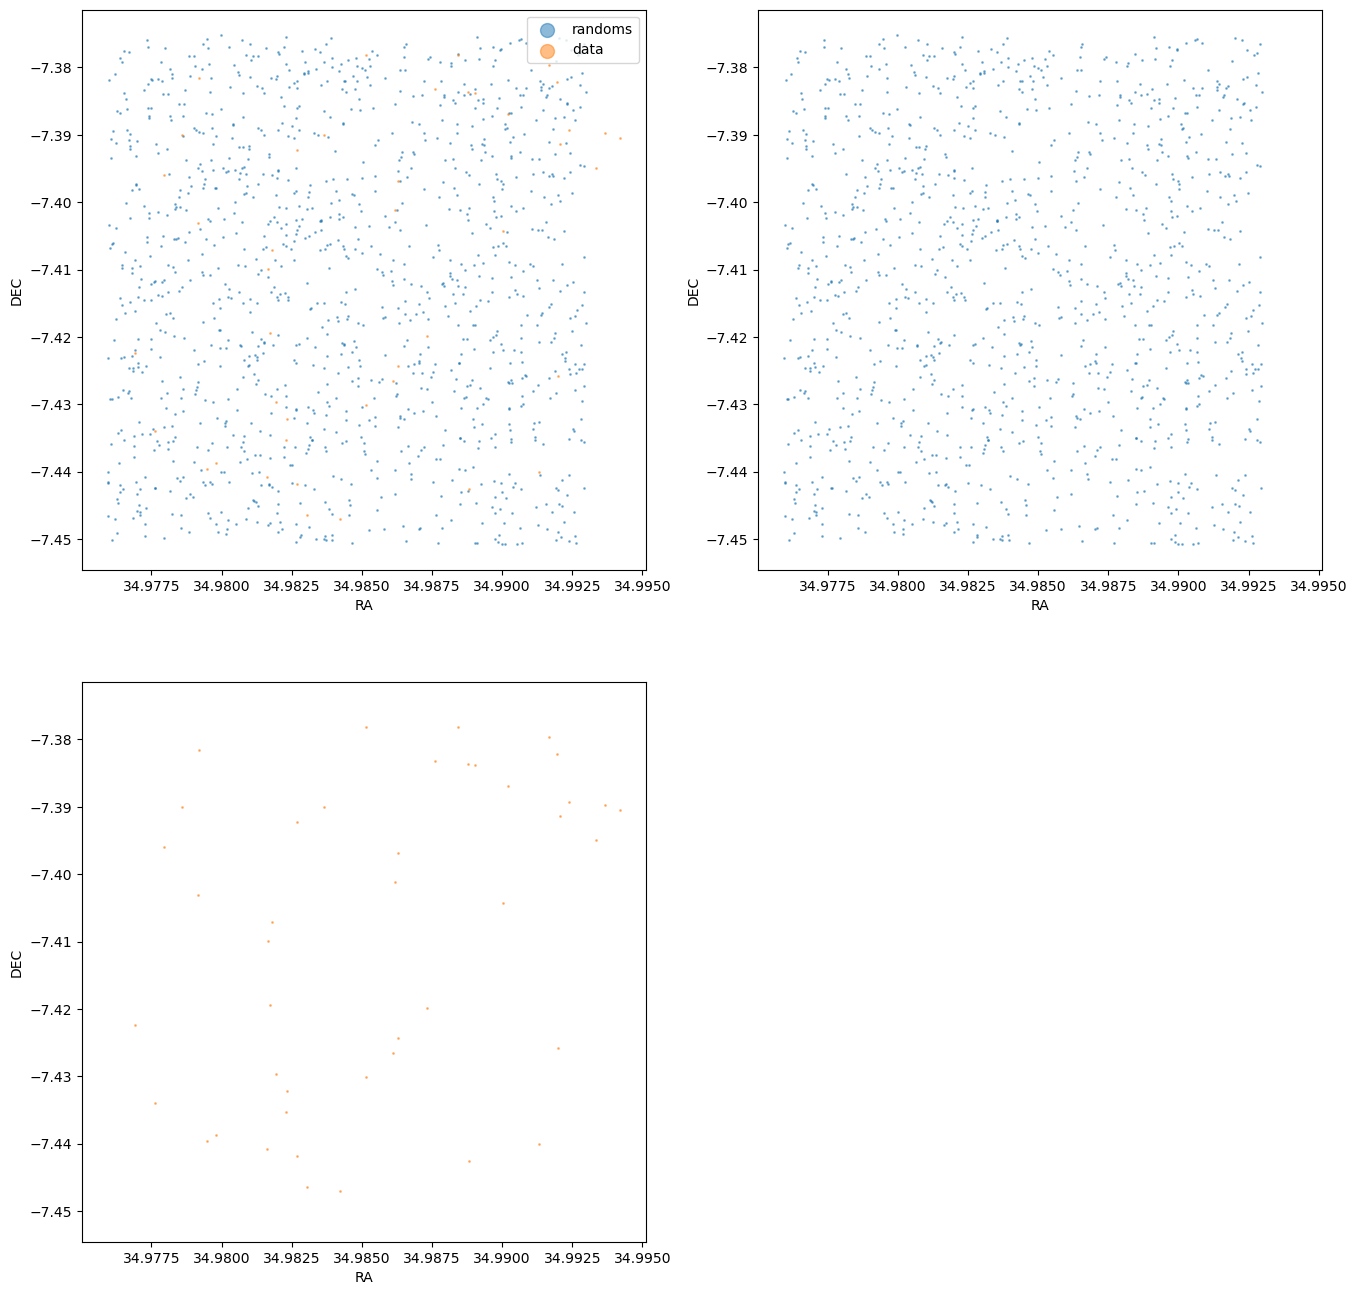

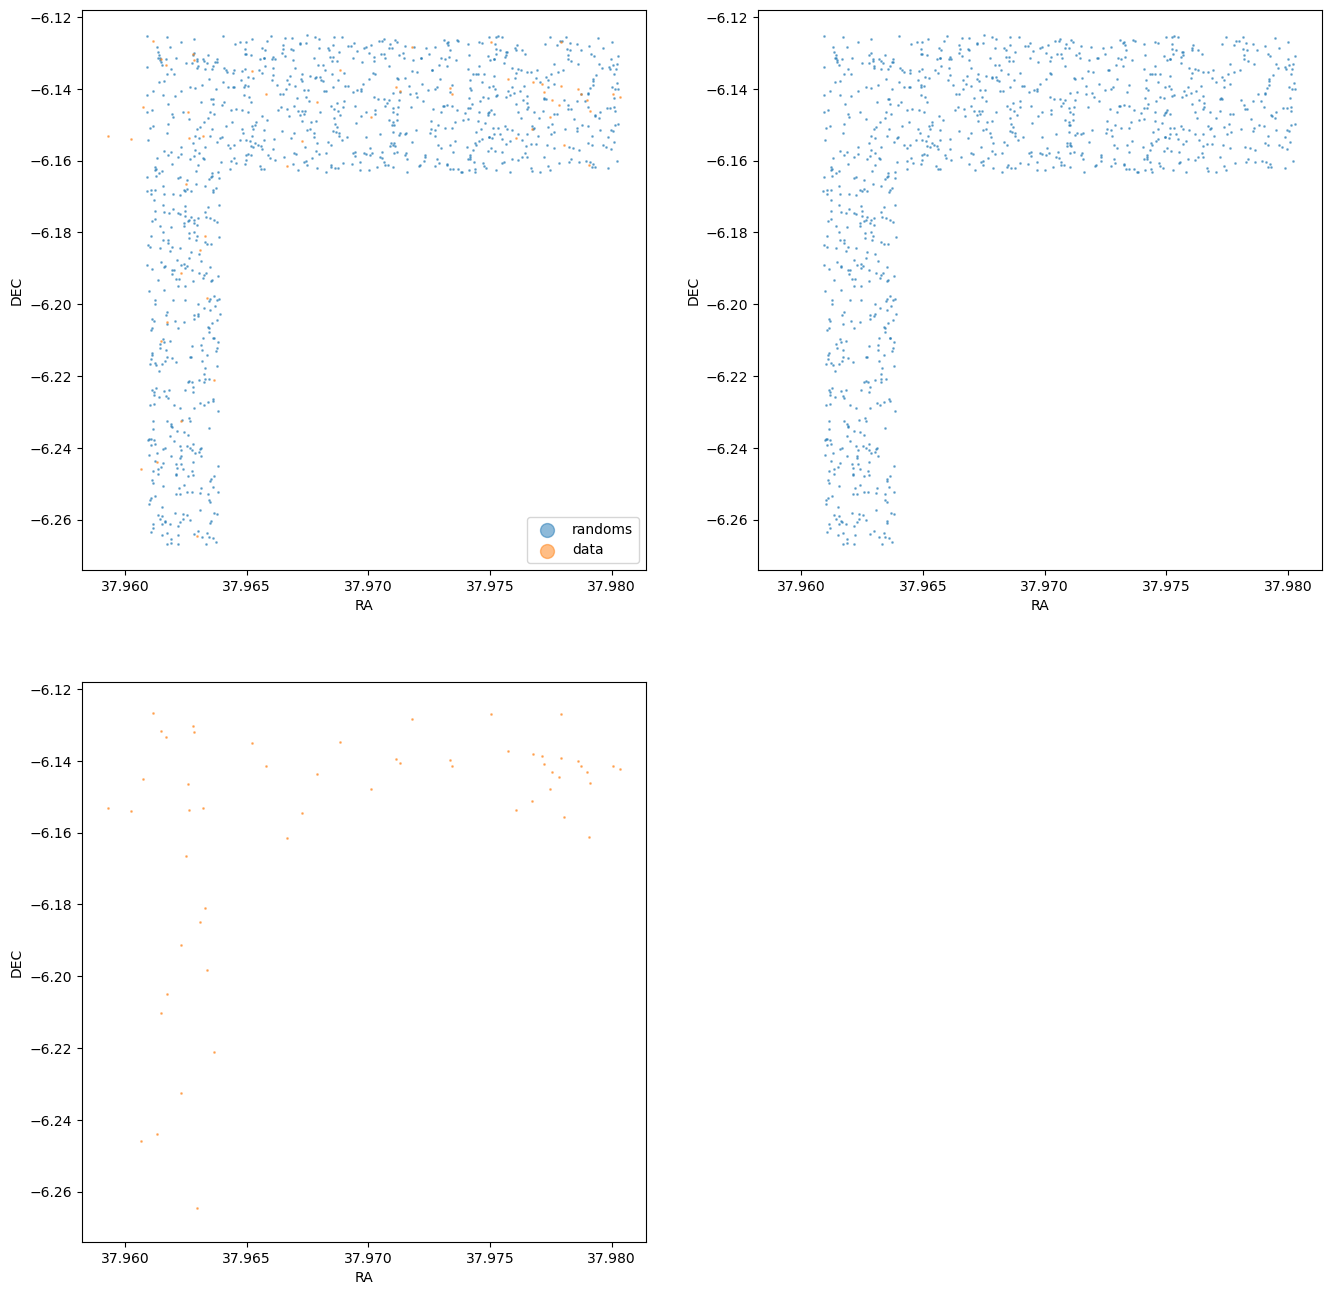

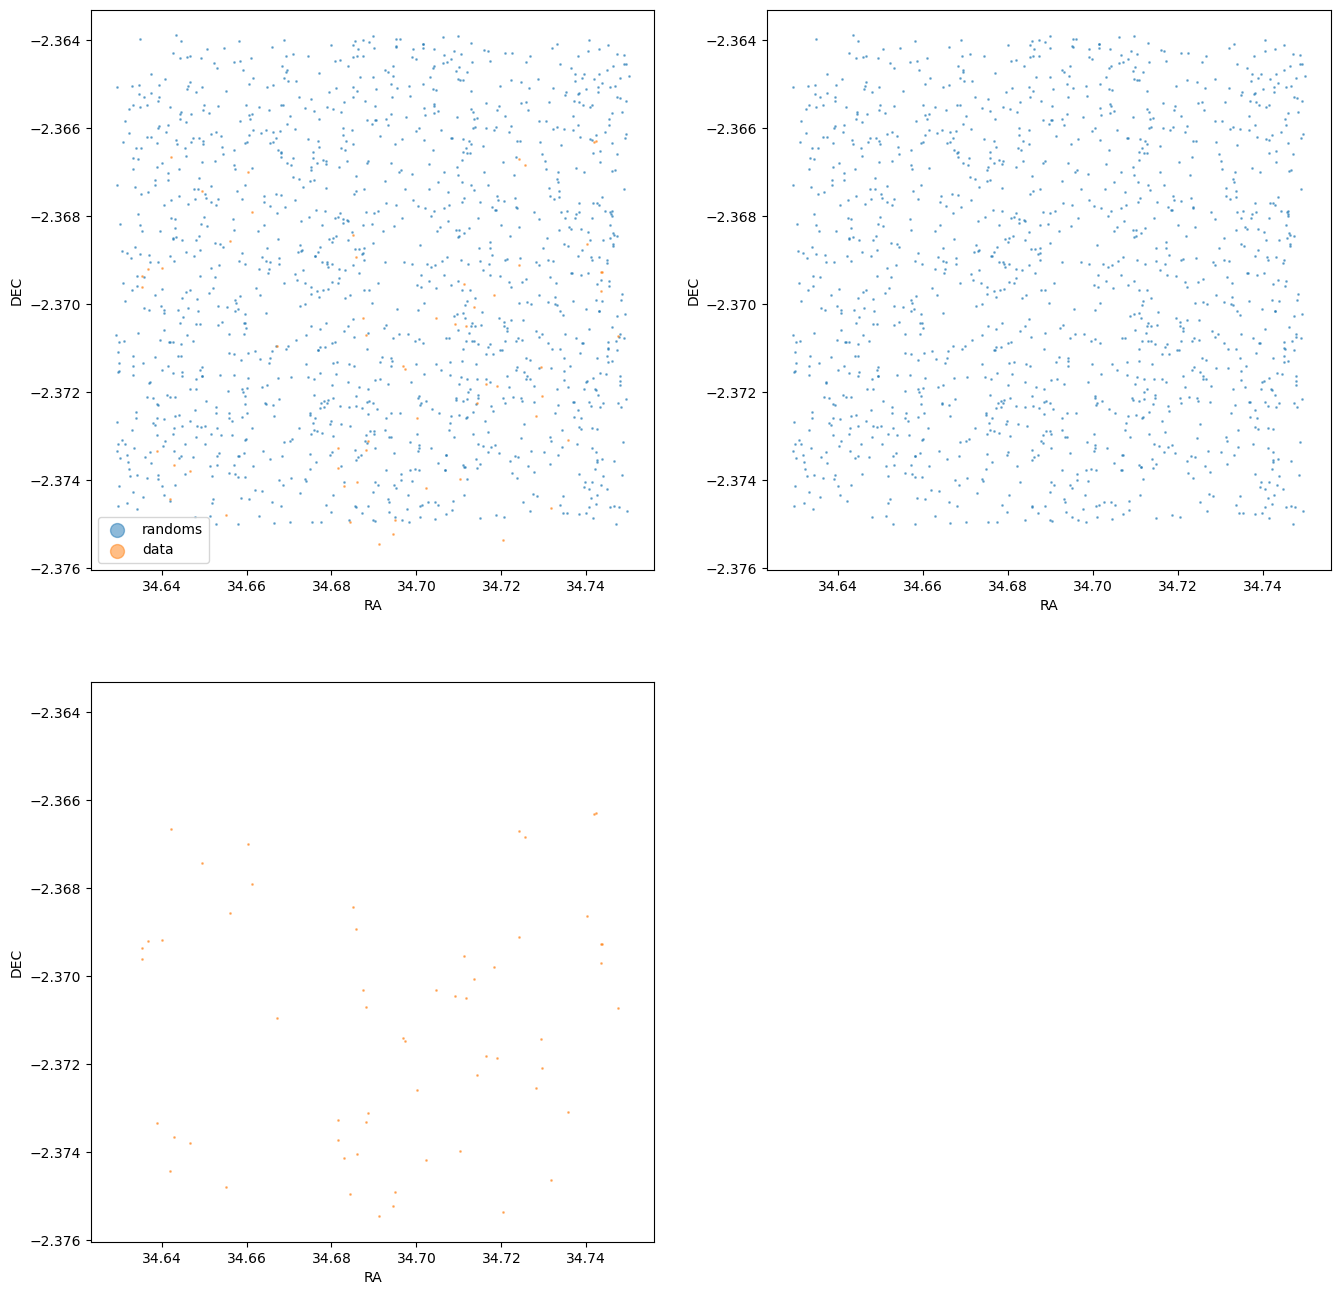

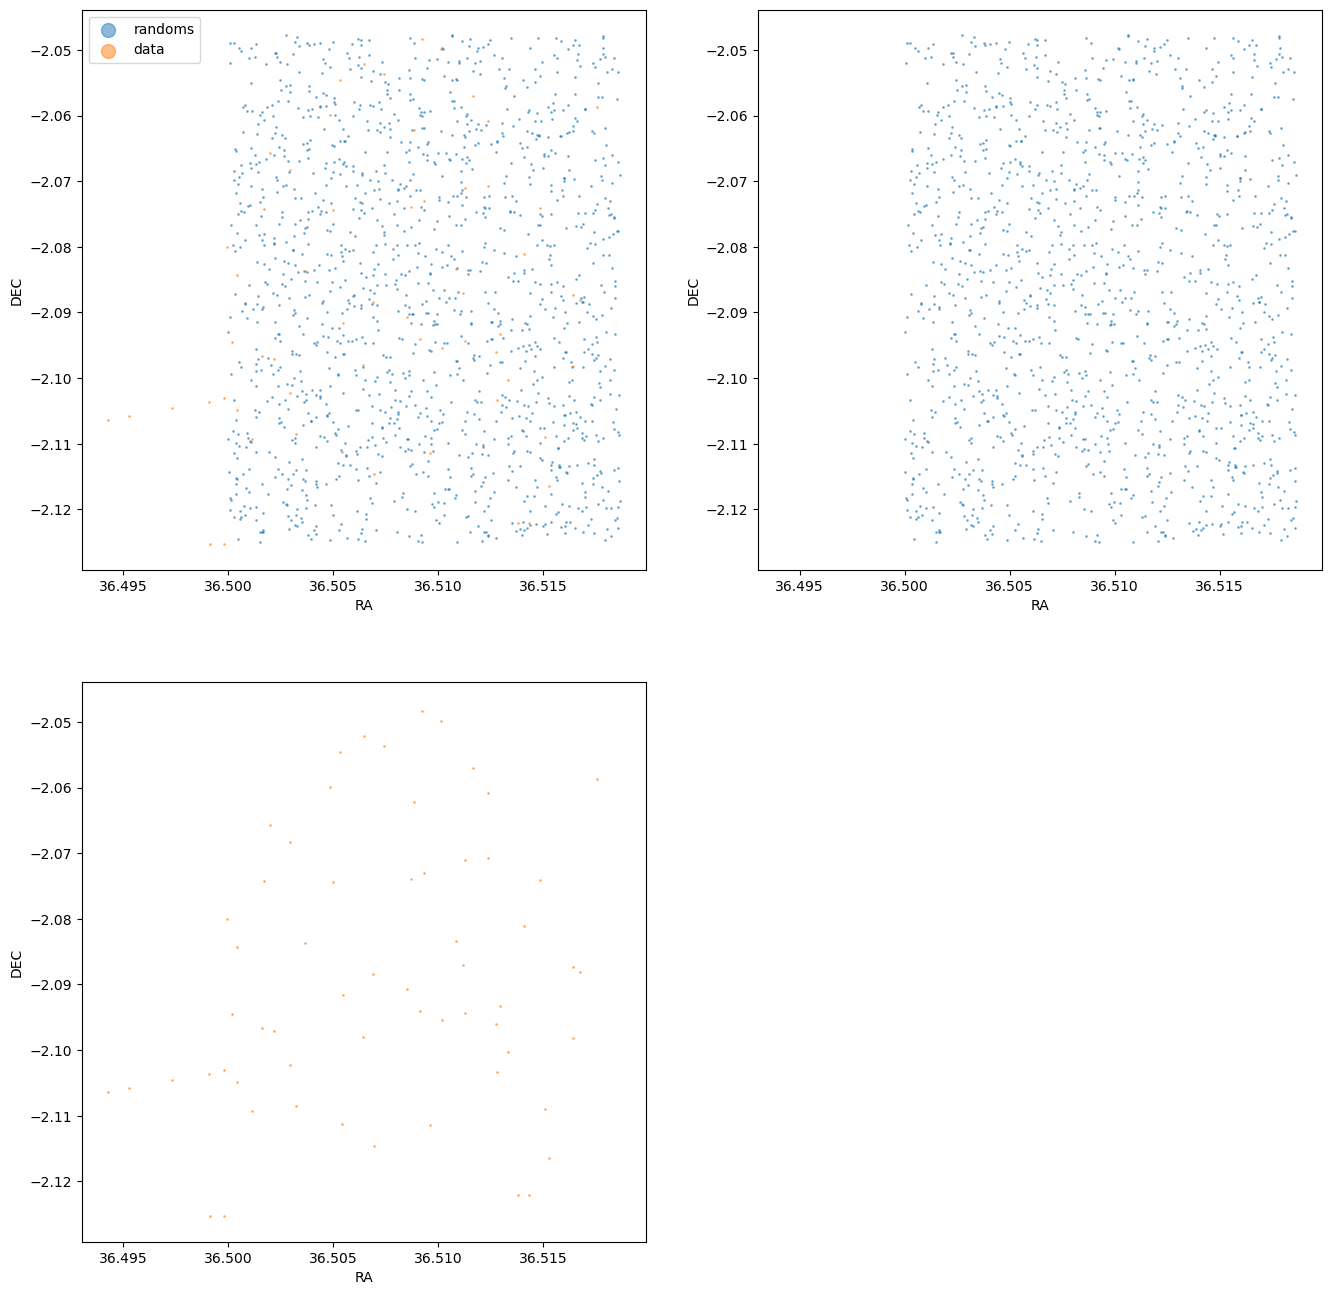

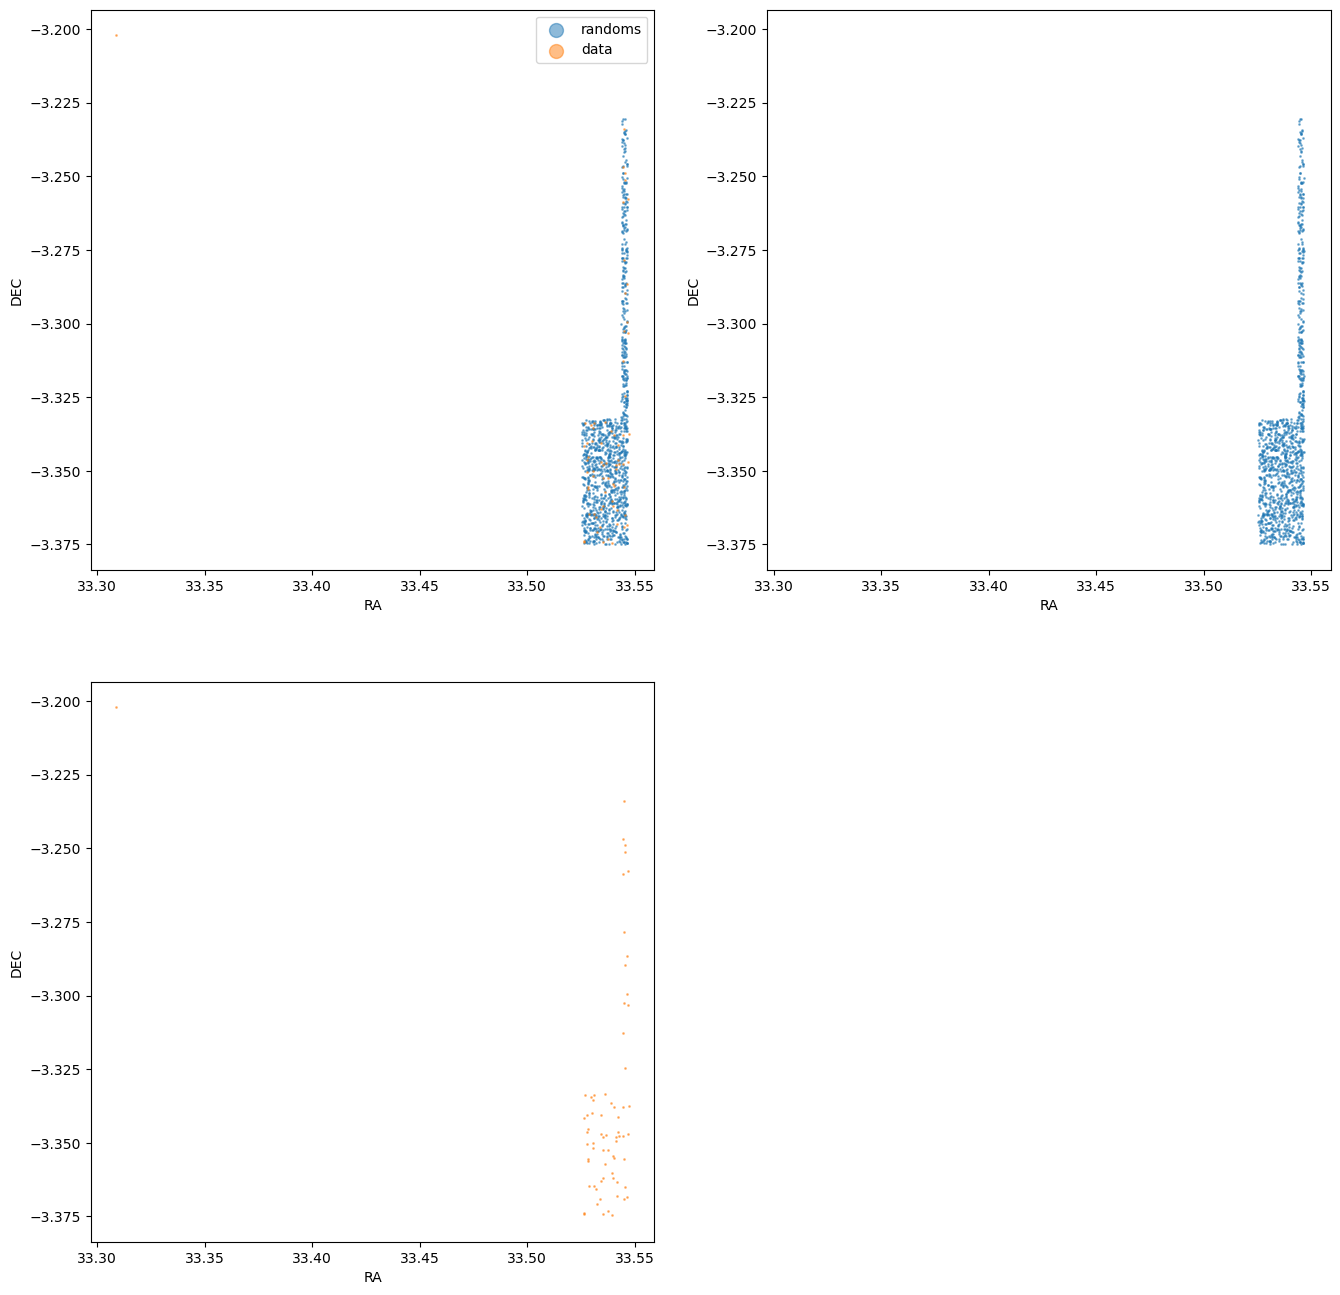

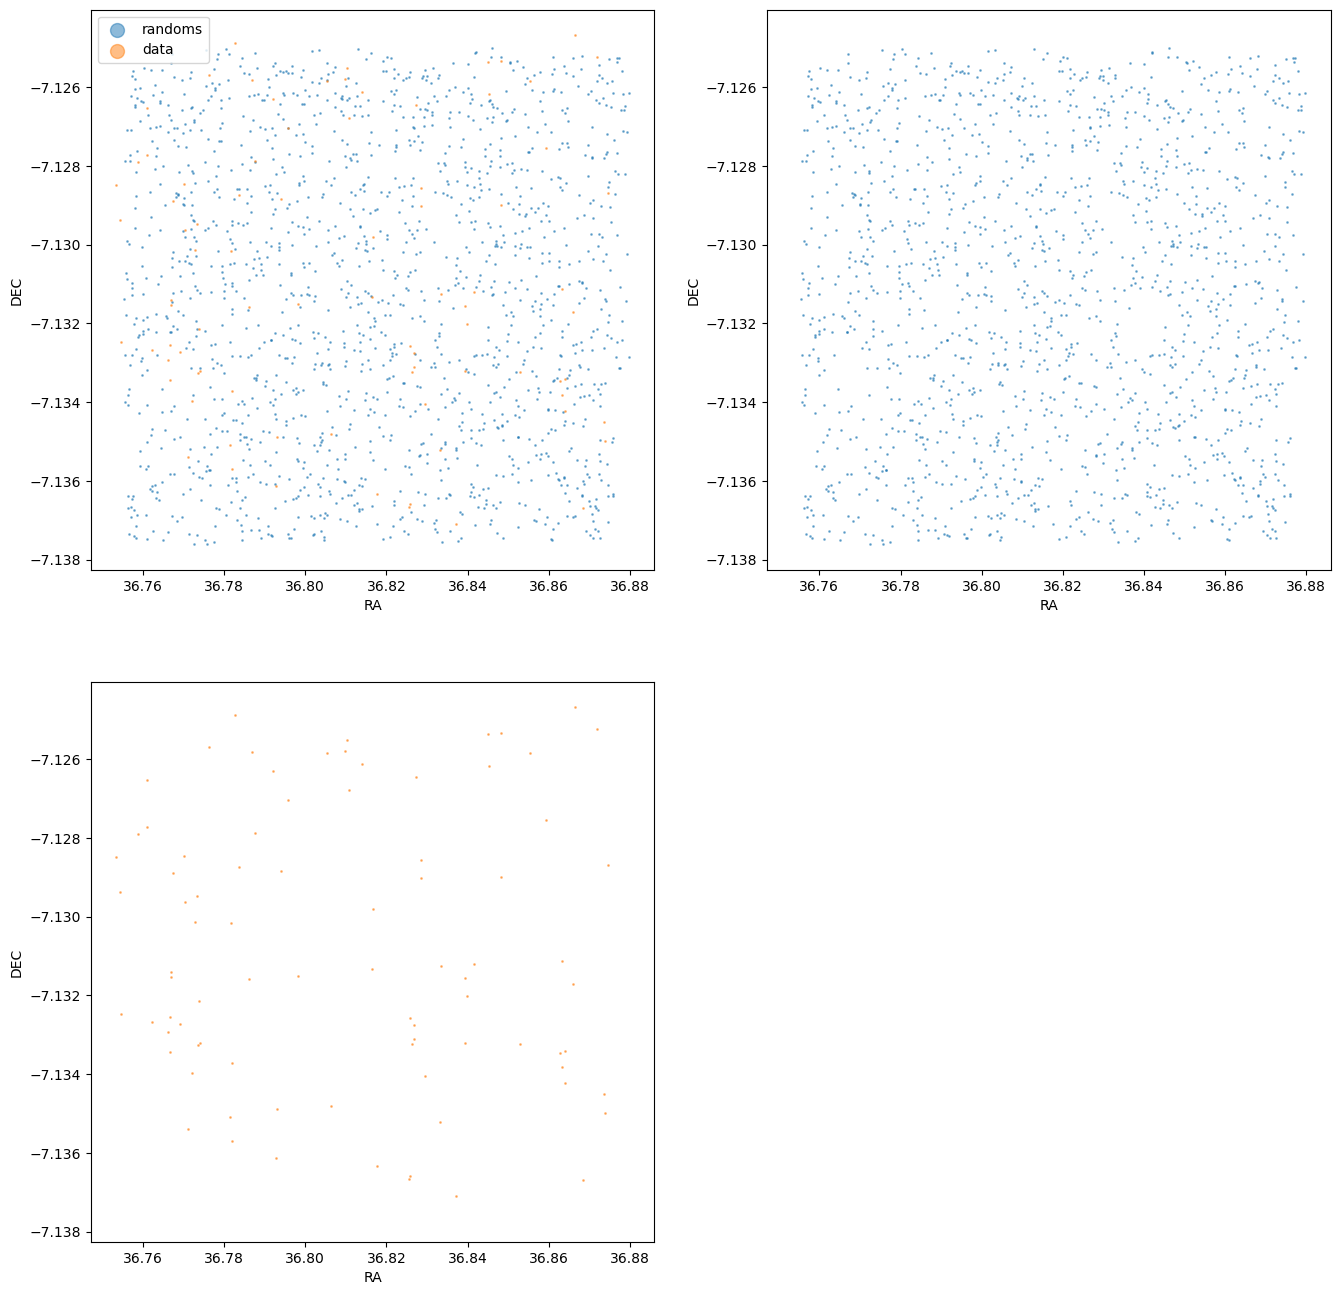

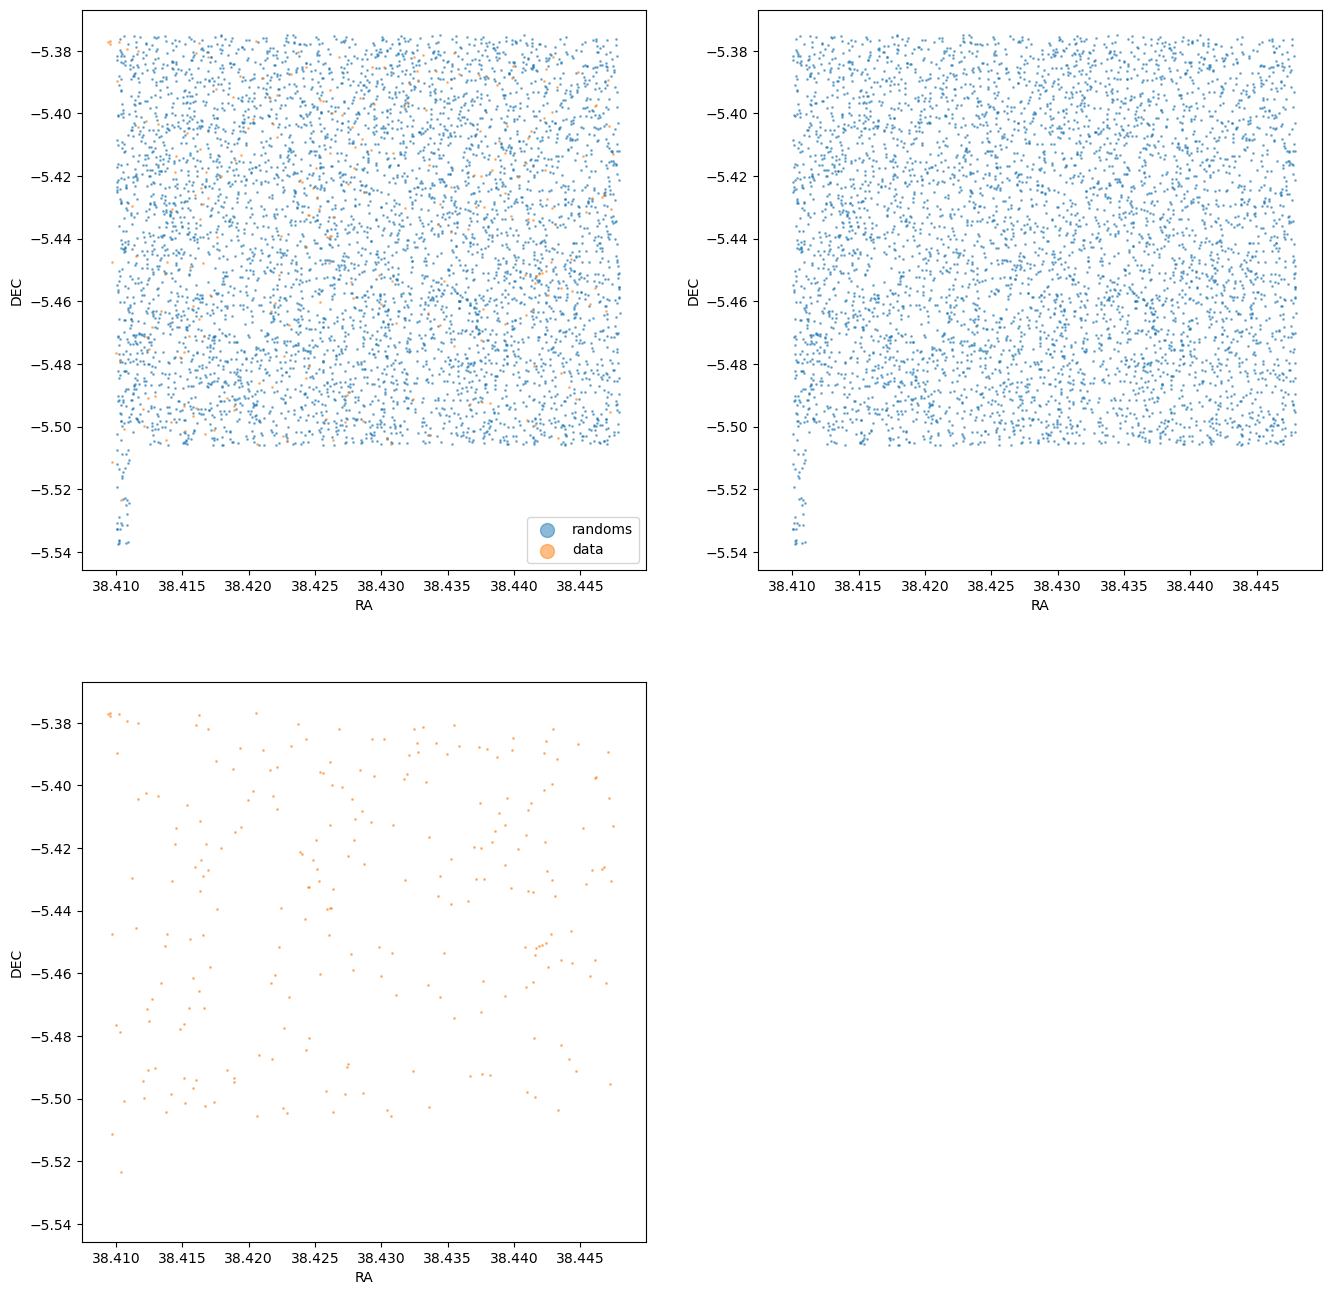

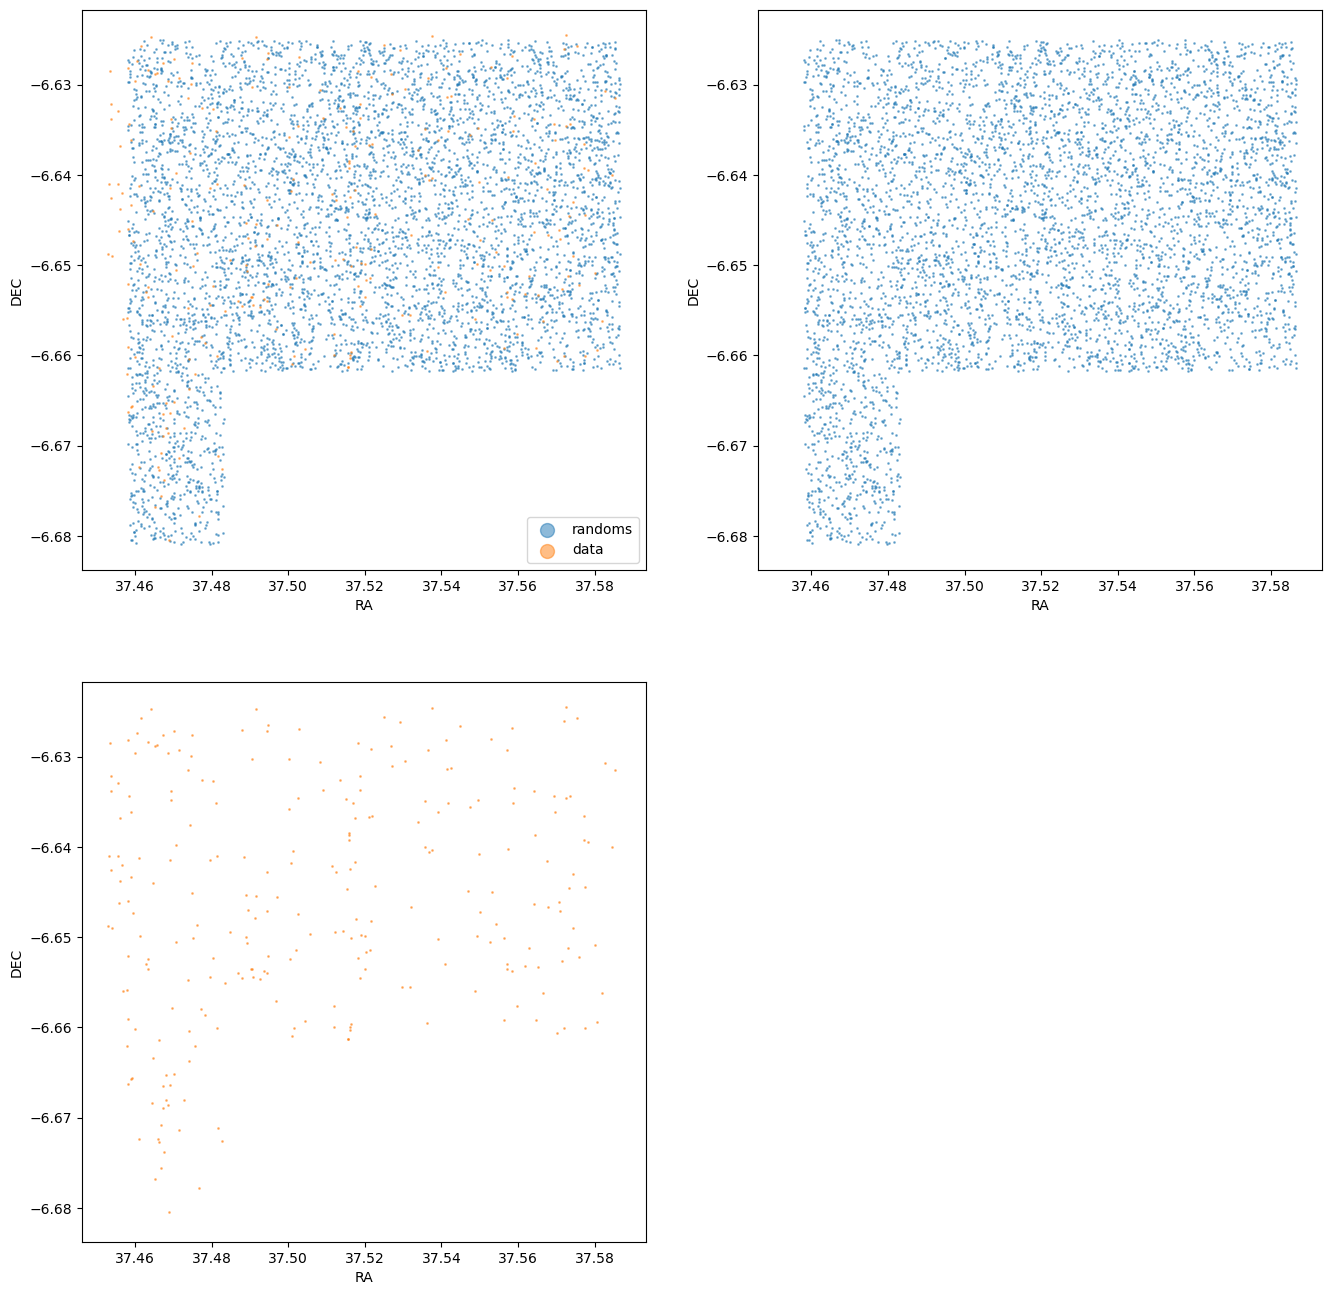

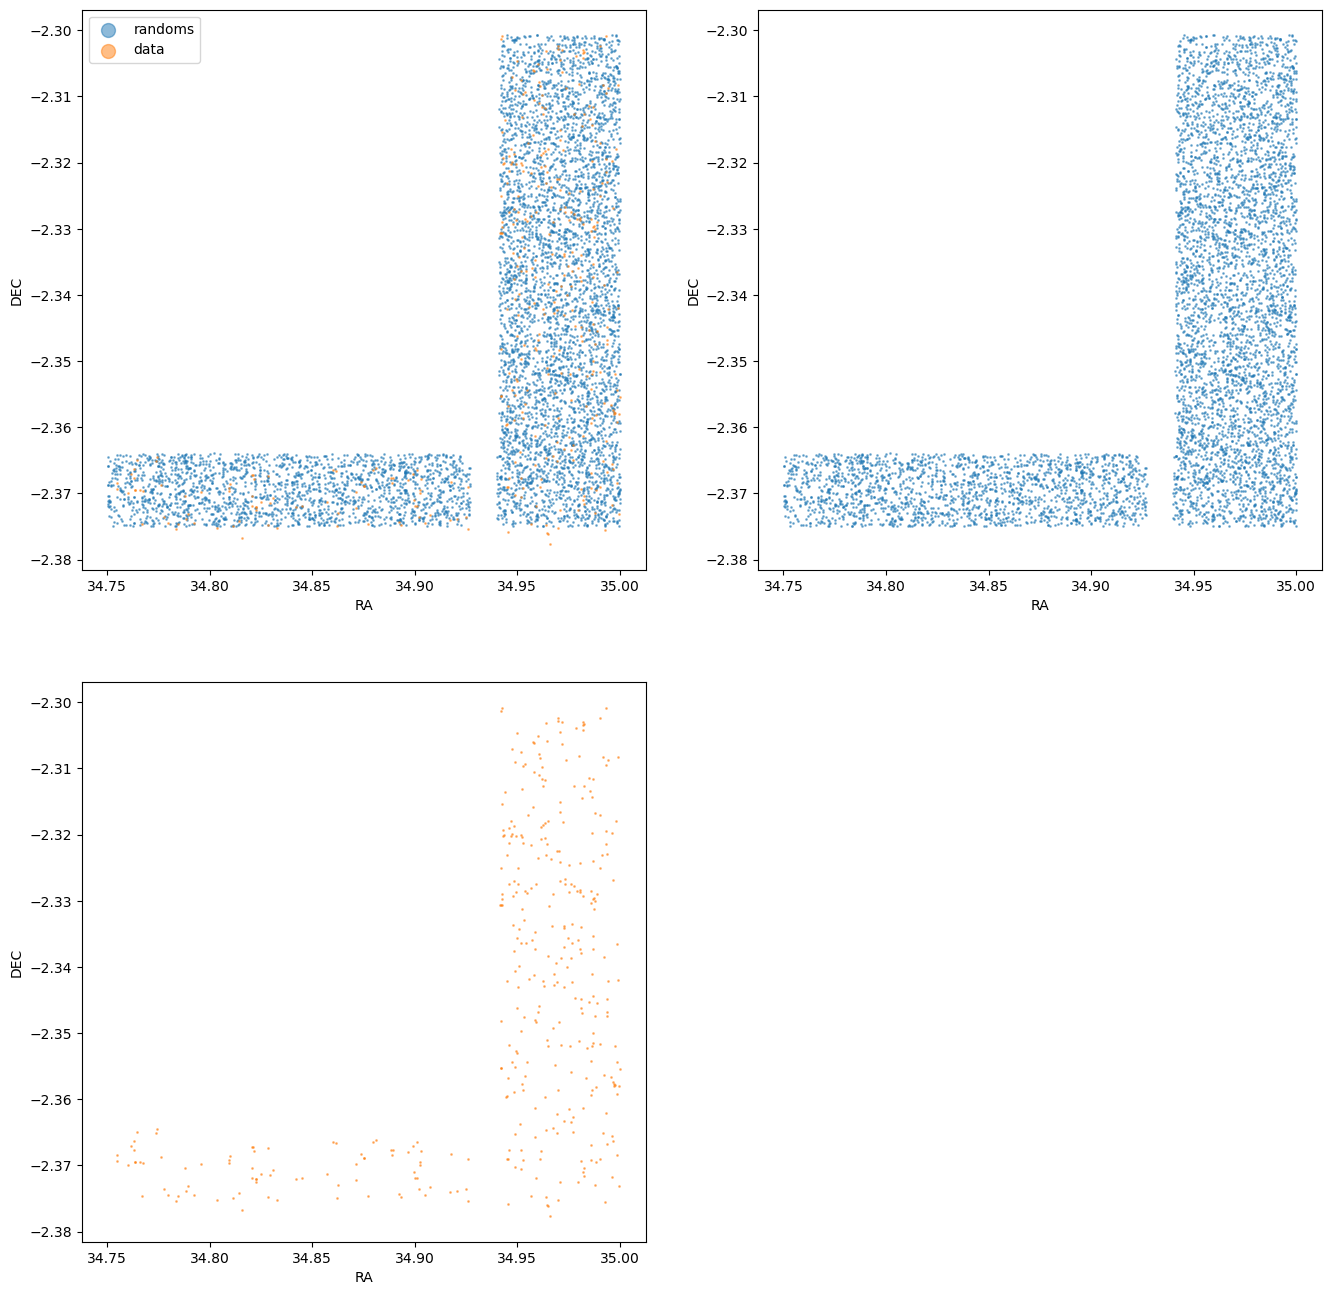

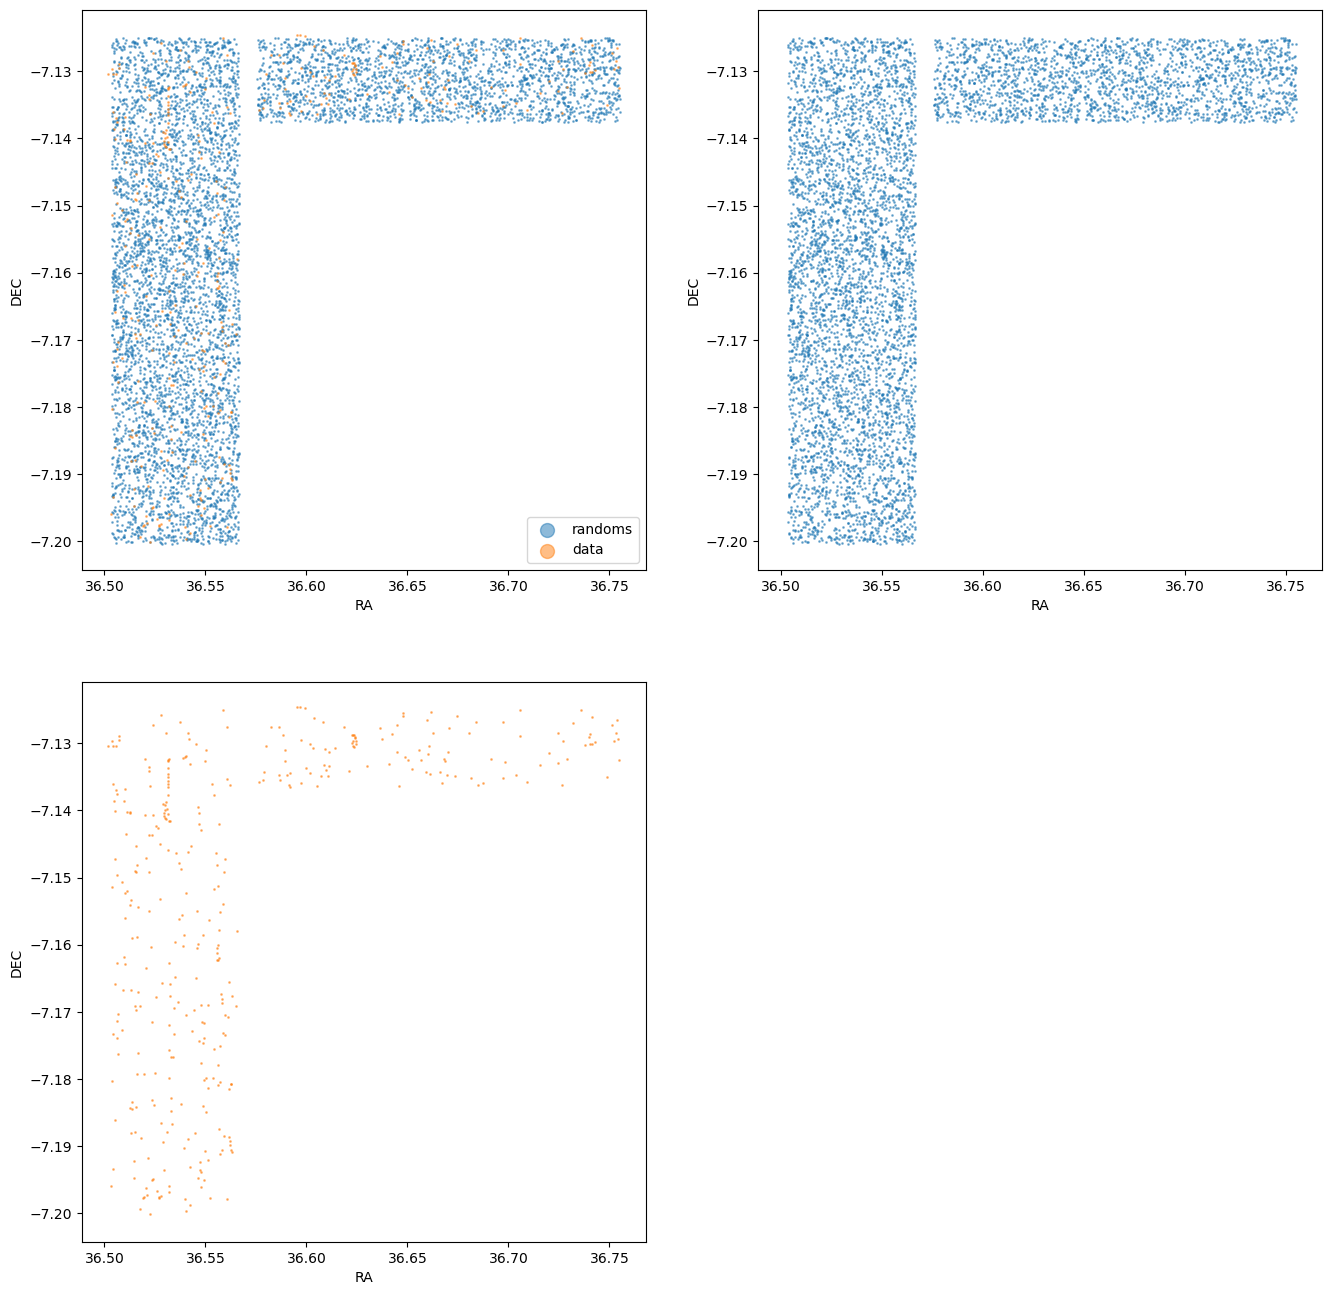

In [48]:
df = pd.read_csv(outdir / "bricks-source-comparison.csv")
df.sort_values('ratio', ascending=False, inplace=True)
for ii in range(10):
    extm_brick = df['brick'].iloc[ii]
    onebr_ratio = df['ratio'].iloc[ii]
    onedatcoord = coords[bricks.index(extm_brick)]
    onerandtab = randtab[randtab['BRICKNAME'] == extm_brick]
    print("The block with extreme ratio is:", extm_brick, "with ratio:", onebr_ratio)
    plot_compare_randoms_data(onerandtab['RA'], onerandtab['DEC'],
                            onedatcoord[0], onedatcoord[1], outdir / f"comp-{extm_brick}-ratio{onebr_ratio:.2f}.png")